#### 1. Loading and preparing Dataset

In [1]:

import yfinance as yf
import pandas as pd
import numpy as np

# Download AAPL data
ticker = 'AAPL'
data = yf.Ticker(ticker).history(period='5y')

# Create returns column
data['returns'] = data['Close'].pct_change()
data = data.dropna()
data.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,returns
Date,,,,,,,,
2020-08-26 00:00:00-04:00,122.737539,123.527873,121.669978,123.070694,163022400,0.0,0.0,0.013599
2020-08-27 00:00:00-04:00,123.673769,124.006924,120.454069,121.599449,155552400,0.0,0.0,-0.011954
2020-08-28 00:00:00-04:00,122.574608,122.992877,121.178760,121.402489,187630000,0.0,0.0,-0.001620
2020-08-31 00:00:00-04:00,124.099333,127.426026,122.562438,125.519493,225702700,0.0,4.0,0.033912
2020-09-01 00:00:00-04:00,129.138029,131.122382,126.968873,130.519287,151948100,0.0,0.0,0.039833


#### 2. Feature Engineering

In [2]:

# Lag features
data['lag_1'] = data['returns'].shift(1)
data['lag_2'] = data['returns'].shift(2)

# Rolling statistics (window=5 days)
data['roll_mean_5'] = data['returns'].shift(1).rolling(window=5).mean()
data['roll_std_5'] = data['returns'].shift(1).rolling(window=5).std()

# Drop NaN values from feature creation
data = data.dropna()
data.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,returns,lag_1,lag_2,roll_mean_5,roll_std_5
Date,,,,,,,,,,,,
2020-09-02 00:00:00-04:00,133.836267,134.215626,123.535186,127.815140,200119000,0.0,0.0,-0.020718,0.039833,0.033912,0.014754,0.022242
2020-09-03 00:00:00-04:00,123.447625,125.324964,117.212500,117.582130,257599600,0.0,0.0,-0.080061,-0.020718,0.039833,0.007890,0.027387
2020-09-04 00:00:00-04:00,116.794217,120.325179,107.864668,117.659935,332607200,0.0,0.0,0.000662,-0.080061,-0.020718,-0.005731,0.048513
2020-09-08 00:00:00-04:00,110.841203,115.743703,109.605855,109.742035,231366600,0.0,0.0,-0.067295,0.000662,-0.080061,-0.005275,0.048572
2020-09-09 00:00:00-04:00,114.060879,115.889586,112.115444,114.119240,176940500,0.0,0.0,0.039886,-0.067295,0.000662,-0.025516,0.049243


#### 3. Create Target Variable

In [3]:

data['y_up'] = (data['returns'].shift(-1) > 0).astype(int)

# Drop last row (no target available)
data = data.dropna()
data.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,returns,lag_1,lag_2,roll_mean_5,roll_std_5,y_up
Date,,,,,,,,,,,,,
2020-09-02 00:00:00-04:00,133.836267,134.215626,123.535186,127.815140,200119000,0.0,0.0,-0.020718,0.039833,0.033912,0.014754,0.022242,0
2020-09-03 00:00:00-04:00,123.447625,125.324964,117.212500,117.582130,257599600,0.0,0.0,-0.080061,-0.020718,0.039833,0.007890,0.027387,1
2020-09-04 00:00:00-04:00,116.794217,120.325179,107.864668,117.659935,332607200,0.0,0.0,0.000662,-0.080061,-0.020718,-0.005731,0.048513,0
2020-09-08 00:00:00-04:00,110.841203,115.743703,109.605855,109.742035,231366600,0.0,0.0,-0.067295,0.000662,-0.080061,-0.005275,0.048572,1
2020-09-09 00:00:00-04:00,114.060879,115.889586,112.115444,114.119240,176940500,0.0,0.0,0.039886,-0.067295,0.000662,-0.025516,0.049243,0


#### 4. Train-Test Split

In [4]:

from sklearn.model_selection import train_test_split

features = ['lag_1', 'lag_2', 'roll_mean_5', 'roll_std_5']
X = data[features]
y = data['y_up']

# Time-aware split (no shuffle)
split_idx = int(len(X)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


## 5. Build Pipeline
We'll build a **Logistic Regression pipeline** with scaling.

In [5]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)


## 6. Model Evaluation
We'll evaluate the model with Accuracy, Precision, Recall, F1, and Confusion Matrix.

Accuracy: 0.524
Precision: 0.532
Recall: 0.872
F1-score: 0.661


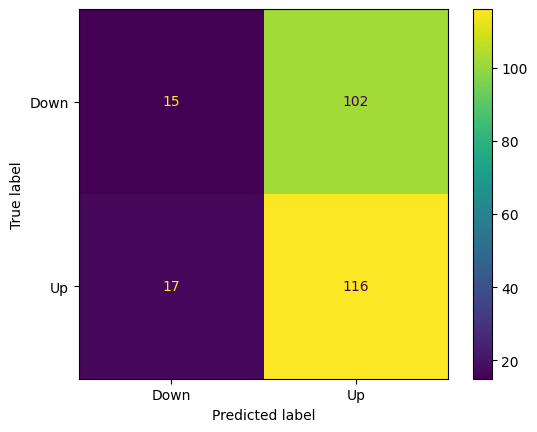

In [6]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down','Up'])
disp.plot()



#### 7. Interpretation
- The model captures some directional patterns, but accuracy is close to baseline, meaning stock movement is still largely random day-to-day.
- Rolling mean and volatility help a bit but are not strong predictors alone.
- Assumptions like stationarity and linear separability may not hold in financial data, so more complex models or feature sets could improve performance.
- Still, this pipeline serves as a **good baseline** for more advanced models like Random Forests, Gradient Boosting, or Neural Networks in the future.
